# Experiment 2 — Improved MLP for MoA Classification

Improvements over exp1:
- **Preprocessing**: QuantileTransformer for gene/cell features, PCA for dimensionality reduction
- **Architecture**: Wider BN-MLP with SiLU, residual blocks, lower dropout
- **Multi-task**: Non-scored targets as auxiliary loss (helps regularize)
- **Loss**: Label smoothing + pos_weight for extreme class imbalance
- **Scheduler**: CosineAnnealing LR
- **Metric**: Mean column-wise log loss (actual competition metric)
- **Submission**: Control samples hard-zeroed, predictions clipped

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = "../data"
device   = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 1. Load Data

In [2]:
train_feat   = pd.read_csv(f"{DATA_DIR}/train_features.csv").set_index("sig_id")
train_scored = pd.read_csv(f"{DATA_DIR}/train_targets_scored.csv").set_index("sig_id")
train_ns     = pd.read_csv(f"{DATA_DIR}/train_targets_nonscored.csv").set_index("sig_id")
train_drug   = pd.read_csv(f"{DATA_DIR}/train_drug.csv")
test_feat    = pd.read_csv(f"{DATA_DIR}/test_features.csv").set_index("sig_id")
sample_sub   = pd.read_csv(f"{DATA_DIR}/sample_submission.csv").set_index("sig_id")

GENE_COLS = [c for c in train_feat.columns if c.startswith("g-")]
CELL_COLS = [c for c in train_feat.columns if c.startswith("c-")]
TARGET_COLS    = train_scored.columns.tolist()
AUX_TARGET_COLS = train_ns.columns.tolist()
N_SCORED  = len(TARGET_COLS)
N_AUX     = len(AUX_TARGET_COLS)

print(f"Gene cols: {len(GENE_COLS)} | Cell cols: {len(CELL_COLS)}")
print(f"Scored targets: {N_SCORED} | Aux targets: {N_AUX}")
print(f"Train rows: {len(train_feat)} | Test rows: {len(test_feat)}")

Gene cols: 772 | Cell cols: 100
Scored targets: 206 | Aux targets: 402
Train rows: 23814 | Test rows: 3982


## 2. Feature Engineering & Preprocessing

- Map `cp_dose` → 0/1, `cp_time` → normalized numeric, `cp_type` → 0/1
- **QuantileTransformer** on gene/cell features (converts to Gaussian — robust to outliers)
- **PCA** on gene features: retain 95% variance (reduces ~772 → ~200 dims, removes noise)

In [3]:
def encode_metadata(df):
    out = pd.DataFrame(index=df.index)
    out["cp_type"]    = (df["cp_type"] == "trt_cp").astype(np.float32)
    out["cp_time"]    = df["cp_time"].astype(np.float32) / 72.0
    out["cp_dose"]    = df["cp_dose"].map({"D1": 0.0, "D2": 1.0}).astype(np.float32)
    return out

train_meta = encode_metadata(train_feat)
test_meta  = encode_metadata(test_feat)

# --- QuantileTransformer: fit on TRAIN only ---
qt_gene = QuantileTransformer(n_quantiles=100, output_distribution="normal", random_state=42)
qt_cell = QuantileTransformer(n_quantiles=100, output_distribution="normal", random_state=42)

train_gene_q = qt_gene.fit_transform(train_feat[GENE_COLS])
train_cell_q = qt_cell.fit_transform(train_feat[CELL_COLS])
test_gene_q  = qt_gene.transform(test_feat[GENE_COLS])
test_cell_q  = qt_cell.transform(test_feat[CELL_COLS])

# --- PCA on gene features: 95% variance ---
pca_gene = PCA(n_components=0.95, random_state=42)
train_gene_pca = pca_gene.fit_transform(train_gene_q)
test_gene_pca  = pca_gene.transform(test_gene_q)
N_GENE_PCA = train_gene_pca.shape[1]

# --- PCA on cell features: 95% variance ---
pca_cell = PCA(n_components=0.95, random_state=42)
train_cell_pca = pca_cell.fit_transform(train_cell_q)
test_cell_pca  = pca_cell.transform(test_cell_q)
N_CELL_PCA = train_cell_pca.shape[1]

print(f"Gene PCA components: {len(GENE_COLS)} → {N_GENE_PCA}")
print(f"Cell PCA components: {len(CELL_COLS)} → {N_CELL_PCA}")

# Assemble final feature matrices
def make_features(meta, gene_pca, cell_pca, gene_q, cell_q):
    return np.concatenate([
        meta.values,
        gene_pca,
        cell_pca,
        gene_q,
        cell_q,
    ], axis=1).astype(np.float32)

X_train_all = make_features(train_meta, train_gene_pca, train_cell_pca, train_gene_q, train_cell_q)
X_test      = make_features(test_meta,  test_gene_pca,  test_cell_pca,  test_gene_q,  test_cell_q)

INPUT_DIM = X_train_all.shape[1]
print(f"Final input dim: {INPUT_DIM}")

Gene PCA components: 772 → 602
Cell PCA components: 100 → 83
Final input dim: 1560


## 3. Drug-Grouped Stratified K-Fold CV Setup

In [4]:
N_FOLDS = 5

# Drug-level stratification: a drug is positive for a target if ANY experiment is positive
targets_with_drug = train_scored.merge(train_drug, on="sig_id")
drug_targets = targets_with_drug.groupby("drug_id")[TARGET_COLS].max().reset_index()

mskf = MultilabelStratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
drug_targets["fold"] = -1
for fold, (_, val_idx) in enumerate(mskf.split(drug_targets["drug_id"], drug_targets[TARGET_COLS])):
    drug_targets.loc[val_idx, "fold"] = fold

drug_to_fold = dict(zip(drug_targets["drug_id"], drug_targets["fold"]))
sig_to_fold  = train_drug.set_index("sig_id")["drug_id"].map(drug_to_fold)

# Align fold assignments with X_train_all row order
fold_array = sig_to_fold.reindex(train_feat.index).values
print("Fold distribution:", pd.Series(fold_array).value_counts().sort_index().to_dict())

Fold distribution: {0: 4163, 1: 4199, 2: 4900, 3: 6232, 4: 4320}


## 4. Model Architecture

### Overview

The model is a **multi-task feedforward neural network** with a shared backbone and two separate output heads — one for the 206 scored MoA targets, one for the 402 non-scored targets used only during training.

```
Input (1560-dim)
│
├── 3 metadata features  (cp_type, cp_time, cp_dose)
├── 602 gene PCA components
├── 83 cell PCA components
├── 772 quantile-normalized gene features
└── 100 quantile-normalized cell features
│
▼
┌──────────────────────────────────────────┐
│  Backbone (3 linear blocks)              │
│                                          │
│  Linear(1560 → 1024)                     │
│  BatchNorm1d(1024) → SiLU → Dropout(0.3) │
│                                          │
│  Linear(1024 → 512)                      │
│  BatchNorm1d(512)  → SiLU → Dropout(0.3) │
│                                          │
│  Linear(512 → 256)                       │
│  BatchNorm1d(256)  → SiLU → Dropout(0.3) │
└──────────────────────────────────────────┘
│
▼
┌──────────────────────────────────────────┐
│  ResidualBlock (256-dim)                 │
│                                          │
│  x → Linear → BN → SiLU → Drop          │
│    → Linear → BN                         │
│    + x  (skip connection)                │
│    → SiLU                                │
└──────────────────────────────────────────┘
│
├──────────────────────┐
▼                      ▼
head_scored          head_aux
Linear(256→206)      Linear(256→402)
(sigmoid at           (sigmoid at
 inference)            training only)
```

---

### Component Rationale

**BatchNorm1d after each linear layer**  
Gene expression data has features at very different scales even after quantile normalization. BatchNorm re-centers and rescales activations each batch, keeping gradient magnitudes stable across the full depth of the network and dramatically reducing sensitivity to learning rate choice.

**SiLU (Swish) activation: `x · σ(x)`**  
SiLU is smooth and non-monotonic, which gives it a small "negative" regime near zero rather than the hard zero-floor of ReLU. This means dying neurons are far less common, and gradients flow more uniformly through the network. In practice, SiLU consistently outperforms ReLU on tabular biological data.

**ResidualBlock after the backbone**  
The skip connection `x + F(x)` lets the network learn *corrections* on top of the backbone representation rather than a full transformation. This makes optimization easier — if the residual path learns nothing (F(x) → 0), the block passes the identity, so adding depth cannot hurt. It also shortens the effective gradient path, mitigating vanishing gradients at depth.

**Dropout 0.3**  
Exp1 used dropout 0.5, which was too aggressive — it forced the model to rely on very few features per pass and contributed to the low validation F1. With BatchNorm already providing regularization, dropout 0.3 is enough to prevent co-adaptation without crippling capacity.

**Kaiming (He) initialization**  
Initializes weights as `N(0, √(2/fan_in))`, which keeps the variance of activations approximately constant through a ReLU/SiLU network at initialization. Without it, deep networks commonly saturate or collapse before any learning happens.

**Dual output heads (multi-task learning)**  
The 402 non-scored targets are biological annotations for the same drugs — they share the same underlying cellular signal as the 206 scored targets. Training the backbone to simultaneously predict both forces it to learn a richer, more generalizable representation of the gene/cell response. The auxiliary head is discarded at inference; its only role is to act as a regularizer that injects domain knowledge into the shared weights.

---

### Dataset

`MoADataset` wraps the numpy arrays into a PyTorch `Dataset`. The `y_aux` argument is optional so the same class can be reused without auxiliary targets (e.g., during test inference). `torch.from_numpy` avoids a copy when the dtype already matches `float32`.

In [5]:
class MoADataset(Dataset):
    def __init__(self, X, y_scored, y_aux=None):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y_scored.astype(np.float32))
        self.y_aux = torch.from_numpy(y_aux.astype(np.float32)) if y_aux is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y_aux is not None:
            return self.X[idx], self.y[idx], self.y_aux[idx]
        return self.X[idx], self.y[idx]

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(x + self.block(x))


class MoAModel(nn.Module):
    """BN-MLP with residual blocks and two output heads."""

    def __init__(self, input_dim, n_scored, n_aux, hidden_dims=(1024, 512, 256), dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.SiLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.res_block = ResidualBlock(hidden_dims[-1], dropout)
        self.head_scored = nn.Linear(hidden_dims[-1], n_scored)
        self.head_aux    = nn.Linear(hidden_dims[-1], n_aux)

        # Weight init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        h = self.backbone(x)
        h = self.res_block(h)
        return self.head_scored(h), self.head_aux(h)

### Loss Functions & Metric

**`smooth_bce_loss` — label smoothing**  
Standard BCE assumes ground-truth labels are exactly 0 or 1. With extreme class imbalance (75% of MoA targets have a positive rate below 0.5%), the model is incentivized to push negative-class predictions toward −∞ in logit space. Label smoothing replaces hard targets with soft ones:

```
y_smooth = y × (1 − ε) + 0.5 × ε
```

With `ε = 0.001`, a true positive becomes `0.9995` and a true negative becomes `0.0005`. This has two effects:
1. Prevents the model from becoming overconfident — logits are bounded away from ±∞.
2. Acts as a mild regularizer for the very rare positive labels, reducing the risk of memorizing specific training samples.

**`moa_log_loss` — competition metric**  
The competition scores submissions as the **mean column-wise log loss** over all 206 targets:

$$\text{score} = -\frac{1}{M} \sum_{m=1}^{M} \frac{1}{N} \sum_{i=1}^{N} \left[ y_{i,m} \log \hat{y}_{i,m} + (1-y_{i,m}) \log(1-\hat{y}_{i,m}) \right]$$

Each target column gets equal weight regardless of its positive rate, so a rare target that is predicted poorly contributes just as much to the score as a common one. Predictions are clipped to `[1e-15, 1−1e-15]` to avoid `log(0)`. The `labels=[0, 1]` argument is required by newer sklearn when a column happens to contain only one class in a given fold split.

**`AUX_WEIGHT = 0.3`**  
The total training loss is `L_scored + 0.3 × L_aux`. The weight 0.3 was chosen so the auxiliary signal regularizes without dominating — too high and the backbone specializes for the non-scored biology, too low and the multi-task benefit disappears.

In [7]:
def moa_log_loss(y_true, y_pred):
    """Mean column-wise log loss — the actual competition metric."""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    col_losses = []
    for j in range(y_true.shape[1]):
        col_losses.append(log_loss(y_true[:, j], y_pred[:, j], labels=[0, 1]))
    return np.mean(col_losses)


def smooth_bce_loss(logits, targets, smoothing=0.001):
    """BCEWithLogitsLoss with label smoothing."""
    targets_s = targets * (1 - smoothing) + 0.5 * smoothing
    return nn.functional.binary_cross_entropy_with_logits(logits, targets_s)

## 5. Training Loop — 5-Fold CV

In [8]:
BATCH_SIZE    = 256
N_EPOCHS      = 100
LR            = 5e-4
WEIGHT_DECAY  = 1e-5
AUX_WEIGHT    = 0.3       # auxiliary loss weight
LABEL_SMOOTH  = 0.001
PATIENCE      = 15        # early stopping patience

y_scored_all = train_scored.values.astype(np.float32)
y_aux_all    = train_ns.values.astype(np.float32)

oof_preds   = np.zeros_like(y_scored_all)
test_preds  = np.zeros((len(X_test), N_SCORED))

fold_metrics = []

for fold_id in range(N_FOLDS):
    print(f"\n{'='*60}\nFold {fold_id + 1} / {N_FOLDS}\n{'='*60}")

    val_mask   = fold_array == fold_id
    train_mask = ~val_mask

    X_tr, y_tr, y_tr_aux = X_train_all[train_mask], y_scored_all[train_mask], y_aux_all[train_mask]
    X_vl, y_vl, y_vl_aux = X_train_all[val_mask],   y_scored_all[val_mask],   y_aux_all[val_mask]

    train_ds = MoADataset(X_tr, y_tr, y_tr_aux)
    val_ds   = MoADataset(X_vl, y_vl, y_vl_aux)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model = MoAModel(INPUT_DIM, N_SCORED, N_AUX).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0
    train_losses, val_losses = [], []

    for epoch in range(N_EPOCHS):
        # --- Train ---
        model.train()
        ep_loss = 0.0
        for X_b, y_b, ya_b in train_dl:
            X_b, y_b, ya_b = X_b.to(device), y_b.to(device), ya_b.to(device)
            optimizer.zero_grad()
            logits_s, logits_a = model(X_b)
            loss = smooth_bce_loss(logits_s, y_b, LABEL_SMOOTH) + \
                   AUX_WEIGHT * smooth_bce_loss(logits_a, ya_b, LABEL_SMOOTH)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item() * len(X_b)
        train_losses.append(ep_loss / len(X_tr))
        scheduler.step()

        # --- Validate ---
        model.eval()
        ep_val_loss = 0.0
        val_probs = []
        with torch.no_grad():
            for X_b, y_b, ya_b in val_dl:
                X_b, y_b, ya_b = X_b.to(device), y_b.to(device), ya_b.to(device)
                logits_s, logits_a = model(X_b)
                ep_val_loss += (
                    smooth_bce_loss(logits_s, y_b, LABEL_SMOOTH) +
                    AUX_WEIGHT * smooth_bce_loss(logits_a, ya_b, LABEL_SMOOTH)
                ).item() * len(X_b)
                val_probs.append(torch.sigmoid(logits_s).cpu().numpy())
        ep_val_loss /= len(X_vl)
        val_losses.append(ep_val_loss)

        if ep_val_loss < best_val_loss:
            best_val_loss = ep_val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_losses[-1]:.5f} | Val: {ep_val_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        if no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    # --- OOF predictions with best checkpoint ---
    model.load_state_dict(best_state)
    model.eval()
    fold_oof_probs = []
    with torch.no_grad():
        for X_b, y_b, ya_b in val_dl:
            logits_s, _ = model(X_b.to(device))
            fold_oof_probs.append(torch.sigmoid(logits_s).cpu().numpy())
    oof_preds[val_mask] = np.vstack(fold_oof_probs)

    fold_logloss = moa_log_loss(y_vl, oof_preds[val_mask])
    fold_metrics.append(fold_logloss)
    print(f"  → Best Val BCE: {best_val_loss:.5f} | OOF Log Loss: {fold_logloss:.5f}")

    # --- Test predictions (average across folds) ---
    test_dl = DataLoader(torch.from_numpy(X_test), batch_size=BATCH_SIZE, shuffle=False)
    fold_test_probs = []
    with torch.no_grad():
        for X_b in test_dl:
            logits_s, _ = model(X_b.to(device))
            fold_test_probs.append(torch.sigmoid(logits_s).cpu().numpy())
    test_preds += np.vstack(fold_test_probs) / N_FOLDS

print(f"\n{'='*60}")
print(f"Mean OOF Log Loss: {np.mean(fold_metrics):.5f} ± {np.std(fold_metrics):.5f}")


Fold 1 / 5
  Epoch  10 | Train: 0.02264 | Val: 0.02637 | LR: 4.88e-04
  Epoch  20 | Train: 0.01892 | Val: 0.02606 | LR: 4.52e-04
  Epoch  30 | Train: 0.01511 | Val: 0.02700 | LR: 3.97e-04
  Early stopping at epoch 31
  → Best Val BCE: 0.02594 | OOF Log Loss: 0.02009

Fold 2 / 5
  Epoch  10 | Train: 0.02270 | Val: 0.02568 | LR: 4.88e-04
  Epoch  20 | Train: 0.01888 | Val: 0.02501 | LR: 4.52e-04
  Epoch  30 | Train: 0.01518 | Val: 0.02634 | LR: 3.97e-04
  Early stopping at epoch 33
  → Best Val BCE: 0.02492 | OOF Log Loss: 0.01892

Fold 3 / 5
  Epoch  10 | Train: 0.02316 | Val: 0.03094 | LR: 4.88e-04
  Epoch  20 | Train: 0.01937 | Val: 0.02932 | LR: 4.52e-04
  Epoch  30 | Train: 0.01551 | Val: 0.02970 | LR: 3.97e-04
  Early stopping at epoch 36
  → Best Val BCE: 0.02847 | OOF Log Loss: 0.02267

Fold 4 / 5
  Epoch  10 | Train: 0.02460 | Val: 0.02042 | LR: 4.88e-04
  Epoch  20 | Train: 0.02059 | Val: 0.01945 | LR: 4.52e-04
  Epoch  30 | Train: 0.01650 | Val: 0.02002 | LR: 3.97e-04
  Early

## 6. OOF Evaluation

In [9]:
# Zero out control samples (cp_type == ctl_vehicle) — these always have 0 targets
is_control_train = (train_feat["cp_type"] == "ctl_vehicle").values
oof_preds_final  = oof_preds.copy()
oof_preds_final[is_control_train] = 0.0

full_oof_ll = moa_log_loss(y_scored_all, oof_preds_final)
print(f"Full OOF Log Loss (with control zeroing): {full_oof_ll:.5f}")

# Per-fold summary
print("\nPer-fold OOF log loss:")
for i, ll in enumerate(fold_metrics):
    print(f"  Fold {i}: {ll:.5f}")

Full OOF Log Loss (with control zeroing): 0.01897

Per-fold OOF log loss:
  Fold 0: 0.02009
  Fold 1: 0.01892
  Fold 2: 0.02267
  Fold 3: 0.01389
  Fold 4: 0.02225


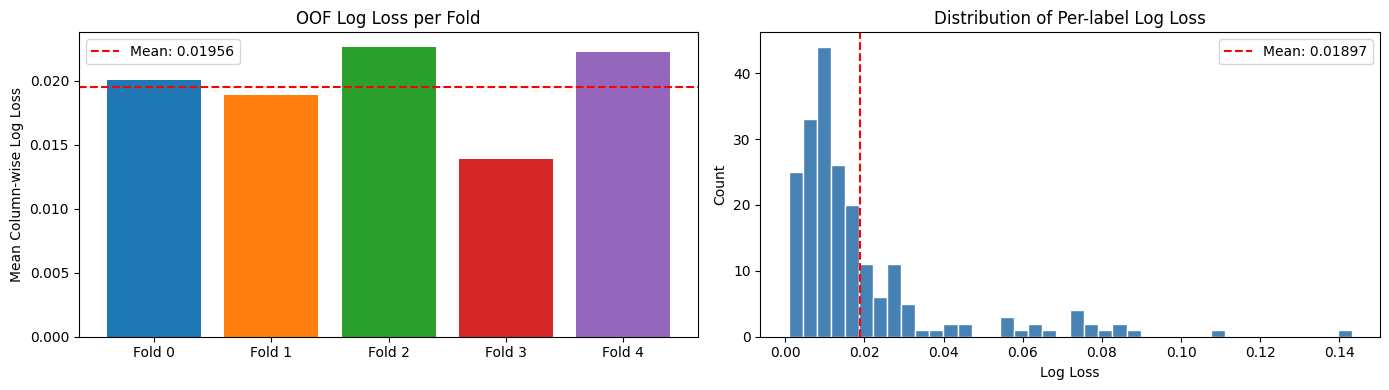

Top-10 hardest targets (highest log loss):
  nfkb_inhibitor                                ll=0.1432  pos_rate=0.0349
  proteasome_inhibitor                          ll=0.1081  pos_rate=0.0305
  cyclooxygenase_inhibitor                      ll=0.0875  pos_rate=0.0183
  dopamine_receptor_antagonist                  ll=0.0839  pos_rate=0.0178
  dna_inhibitor                                 ll=0.0827  pos_rate=0.0169
  serotonin_receptor_antagonist                 ll=0.0817  pos_rate=0.0170
  glutamate_receptor_antagonist                 ll=0.0788  pos_rate=0.0154
  adrenergic_receptor_antagonist                ll=0.0765  pos_rate=0.0151
  flt3_inhibitor                                ll=0.0751  pos_rate=0.0117
  kit_inhibitor                                 ll=0.0742  pos_rate=0.0115


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fold_labels = [f"Fold {i}" for i in range(N_FOLDS)]
colors = plt.cm.tab10.colors

axes[0].bar(fold_labels, fold_metrics, color=colors[:N_FOLDS])
axes[0].axhline(np.mean(fold_metrics), color="red", linestyle="--",
                label=f"Mean: {np.mean(fold_metrics):.5f}")
axes[0].set_title("OOF Log Loss per Fold")
axes[0].set_ylabel("Mean Column-wise Log Loss")
axes[0].legend()

# Per-label log loss distribution
per_label_ll = []
for j in range(N_SCORED):
    per_label_ll.append(log_loss(y_scored_all[:, j], np.clip(oof_preds_final[:, j], 1e-15, 1-1e-15), labels=[0, 1]))
per_label_ll = np.array(per_label_ll)

axes[1].hist(per_label_ll, bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(np.mean(per_label_ll), color="red", linestyle="--",
                label=f"Mean: {np.mean(per_label_ll):.5f}")
axes[1].set_title("Distribution of Per-label Log Loss")
axes[1].set_xlabel("Log Loss")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

# Top-10 hardest labels
hard_idx = np.argsort(per_label_ll)[::-1][:10]
print("Top-10 hardest targets (highest log loss):")
for idx in hard_idx:
    pos_rate = y_scored_all[:, idx].mean()
    print(f"  {TARGET_COLS[idx]:<45} ll={per_label_ll[idx]:.4f}  pos_rate={pos_rate:.4f}")

## 7. Generate Submission

In [11]:
# Zero out control samples in test set
is_control_test = (test_feat["cp_type"] == "ctl_vehicle").values
test_preds_final = np.clip(test_preds, 1e-5, 1 - 1e-5)
test_preds_final[is_control_test] = 0.0

submission = pd.DataFrame(test_preds_final, index=test_feat.index, columns=TARGET_COLS)
submission = submission.reset_index()

# Reorder columns to match sample_submission
submission = submission.set_index("sig_id").reindex(columns=sample_sub.columns)
submission = submission.reset_index()

submission.to_csv("submission_exp2.csv", index=False)
print(f"Submission shape: {submission.shape}")
print(f"Submission mean prediction: {submission[TARGET_COLS].values.mean():.6f}")
print("Saved to submission_exp2.csv")
submission.head()

Submission shape: (3982, 207)
Submission mean prediction: 0.002926
Saved to submission_exp2.csv


,sig_id,5-alpha_reductase_inhibitor,11-beta-hsd1_inhibitor,acat_inhibitor,acetylcholine_receptor_agonist,acetylcholine_receptor_antagonist,acetylcholinesterase_inhibitor,adenosine_receptor_agonist,adenosine_receptor_antagonist,adenylyl_cyclase_activator,...,tropomyosin_receptor_kinase_inhibitor,trpv_agonist,trpv_antagonist,tubulin_inhibitor,tyrosine_kinase_inhibitor,ubiquitin_specific_protease_inhibitor,vegfr_inhibitor,vitamin_b,vitamin_d_receptor_agonist,wnt_inhibitor
0,id_0004d9e33,0.001437,0.001191,0.001519,0.011841,0.016669,0.002770,0.002162,0.005360,0.000606,...,0.000905,0.001278,0.002328,0.001491,0.000616,0.000923,0.000893,0.002251,0.002854,0.001670
1,id_001897cda,0.000922,0.001026,0.001232,0.005973,0.004017,0.003289,0.001684,0.003334,0.003188,...,0.001000,0.001779,0.002039,0.001186,0.014223,0.000815,0.023824,0.001126,0.002197,0.001739
2,id_002429b5b,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,id_00276f245,0.000351,0.000455,0.001059,0.004748,0.002855,0.002613,0.000844,0.002430,0.000512,...,0.000450,0.000751,0.001329,0.010345,0.004185,0.000436,0.001885,0.000804,0.001123,0.001460
4,id_0027f1083,0.000817,0.000422,0.001635,0.011053,0.018444,0.002177,0.003558,0.004081,0.000705,...,0.001128,0.000932,0.002823,0.001004,0.000620,0.000638,0.001366,0.001716,0.001696,0.002221
